# Classifiers in scikit-learn
In this notebook, we will investigate another binary classification problem using tools from the `scikit-learn` package.

**Learning Objectives**

By the end of this notebook, you should be able to:
1. Implement perceptron and logistic regression models in `scikit-learn`.
2. Split data into training and testing sets.
3. Formulate a classification problem with multiple input features.

**Import modules**

Begin by importing soem of the modules to be used in this notebook

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Introducing scikit-learn

So far, we have been coding everything from scratch in Python. The benefit of coding from scratch is that we can see what is going on under the hood in our models. However, this tends to slow things down. Luckily, people have worked to generalize all of this code into a framework. In this notebook, we'll rely on tools provided in the `scikit-learn` package that largely mirror our han-written Python classes from the past two notebooks.

Let's import some convenient tools from `scikit-learn`:

In [42]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

### A Classification Problem

In this notebook, we'll explore data from the study *Sex-specific prey partitioning in breeding piscivorous birds examined via a novel, noninvasive approach* by Thalinger et al 2018 (Article: [HERE](https://doi.org/10.1002/ece3.4421), Data: [HERE](https://doi.org/10.5061/dryad.b30c555)). Their study focused on cormorants, as seen in their Figure 1:

<img src="cormorant.jpg" alt="Image of a Cormorant from Thalinger et al 2018" width="500">


Let's read in their data and see what it looks like:

In [5]:
# read in the data
df = pd.read_csv('data_thalinger.csv')

# print out the data frame head
df.head()

,MOLECULAR SEXING,Sample number,season,sampling session,cormorant sex,RFU peak 1,RFU peak 2,MOLECULAR FISH IDENTIFICATION,Anguilla anguilla,Lota lota,...,Cyprinidae,Salmo trutta.2,Coregonus spp..2,Perca fluviatilis.2,Sander lucioperca.2,Gymnocephalus spp..1,Esox lucius.2,Lota lota.2,Anguilla anguilla.2,NID
0,NaN,S47,breeding 2012,1,female,0.7266,2.5214,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0
1,NaN,S278,breeding 2012,2,female,0.2766,1.5678,NaN,0,0,...,0,0,0,0,1,7,0,0,0,0
2,NaN,S279,breeding 2012,2,female,1.1432,4.6372,NaN,0,0,...,3,0,0,0,0,0,0,0,0,5
3,NaN,S280,breeding 2012,2,male,NaN,0.6069,NaN,0,0,...,0,0,0,6,0,0,0,0,0,0
4,NaN,S281,breeding 2012,2,female,0.4236,2.5711,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0


In this data, we can see that there is a column for the cormorant sex for each pellet sample and many columns for the presence or absence of a given fish species in the regurgitated pellets. In this notebook, we'll see if we can create a classification model to predict the sex of a cormorant given the presence or absence of molecularly-identified fish in regurgitated pellets.

Note that this type of model is the same as the previous one for sea lions - the only difference is that we will now use 27 different input features for the model (one for the presence/absence of each fish species) rather than just two (skull size and body length, in the case of the sea lions). While these additional features will prevent us from visulalizing the data on a nice graph, they can be used in the exact same way as inputs to our model.

### Preparing the data
First up, we'll need a to convert the text labels "male" and "female" into a binary classification (1's and 0's). This new data will form our target classification vector $y$:

In [56]:
df['classification'] = 1
df.loc[df['cormorant sex']=='male', "classification"] = 0
y = df['classification']

Next up, we'll create our *design matrix* from the identification flags of each fish species. Looking at the spread sheet, these finish specifies are in columns 8-35, we can make our design matrix as follows:

In [57]:
X = np.array(df.iloc[:, 8:36])

For reference, the columns of this matrix correspond to the followins species:

In [58]:
species = df.iloc[:, 8:36].columns.tolist()
for s in species: print(s)

Anguilla anguilla
Lota lota
Esox lucius
Rutilus rutilus
Phoxinus phoxinus
Abramis brama
Alburnus mento
Barbus barbus
Rutilus virgo
Squalius cephalus
Leuciscus spp.
Scardinius erythrophthalmus
Carassius spp.
Tinca tinca
Leuciscus aspius
Vimba vimba
Cyprinus carpio
Alburnoides bipunctatus
Alburnus alburnus
Oncorhynchus mykiss
Salvelinus spp.
Thymallus thymallus
Salmo trutta
Coregonus spp.
Lepomis gibbosus
Sander lucioperca
Perca fluviatilis
Gymnocephalus spp.


As one final step in our pre-processing, we'll remove the samples where none of the fish were identified since this null data does not help us understand links between the diet and sex of cormorants.

In [59]:
# identify rows without an identifications
nonzero_indices = np.sum(X,axis=1)!=0

# subset the design matrix and features
X=X[nonzero_indices,:]
y=y[nonzero_indices]

### Training and Testing Data Sets

In our previous examples, we have used all of our data in the creation of our model. This is a good way to optimize a model to given data set, but it doesn't give us a way to quantify how well our model might be performing on unseen data - in other words, it's ability to generalize to data it has not seen before. When developing machine learning models, it is common practice to divide a data set into two different sets - one for *training* the model and then another to *test* how the model is performing. Since this is quite common, there is a function built into `scikit-learn` for this purpose:

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We can see above that we random choose samples from our design matrix $X$ to include in the training set and keep the remainder for the test set. The flag `test_size=0.2` indicates that 20% of the data will be used for testing and the `random_state=42` is included for reproducibility. The final flag `stratify=y` ensures that the testing and training sets have roughly equivalent proportions of samples from each class. We cancheck this as follows:

In [63]:
print(np.sum(y_train)/len(y_train))
print(np.sum(y_test)/len(y_test))

0.44876325088339225
0.4507042253521127


### Perceptrons in scikit-learn

Perceptrons are common classfication models and they are implemented in `scikit-learn` with the `Perceptron` class. Under the hood, this is nearly identical to our previous implementation in the perceptron notebook - and making the model works the same way: 

In [64]:
# Create and train the Perceptron model
# eta0 is the learning rate
perceptron_model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron_model.fit(X_train, y_train);

Much less code than before! We can see how well our model is performing by running it on the test set:

In [65]:
y_pred = perceptron_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f} %")

Accuracy: 52.11 %


Hmm, not very good - our model is only guess about half of the classifications correctly. What's going on here? One way we can dig into our results is to examine a "confusion matrix" - a visualization of the true positives, true negatives, false positives, and false negatives:

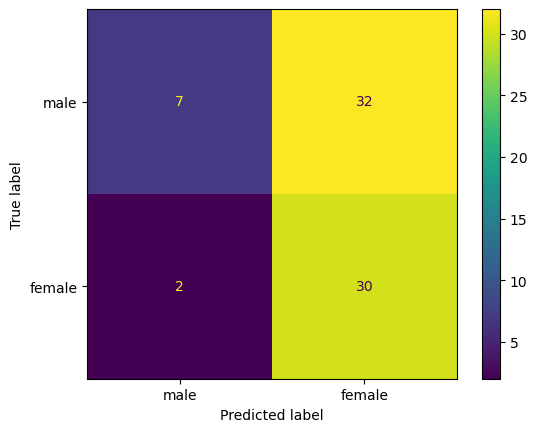

In [73]:
ConfusionMatrixDisplay.from_predictions(y_test, perceptron_model.predict(X_test),
                                        display_labels=['male', 'female']);

What did our model learn? 

### Logistic Regression in scikit-learn

Just like the `Perceptron` class, there is also a class for `LogisticRegression` in scikit-learn! Let's try out a Logistic Regression model for our data: 

In [74]:
logistic_regression_model = LogisticRegression(random_state=42)
logistic_regression_model.fit(X_train, y_train);

As before, let's check the accuracy of the model:

In [75]:
y_pred = logistic_regression_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f} %")

Accuracy: 59.15 %


A bit better than before - let's see what the model is getting right and wrong: 

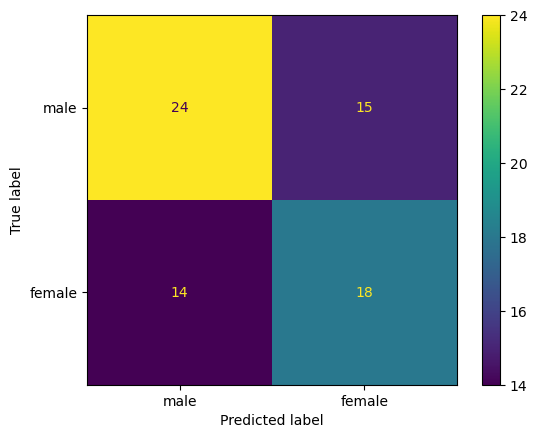

In [76]:
ConfusionMatrixDisplay.from_predictions(y_test, logistic_regression_model.predict(X_test_scaled),
                                        display_labels=['male', 'female']);

Ah, much different results in this model. What do you observe in the behavior of this model relative to the previous one?

Clearly, neither of these models are performing with great accuracy on this classification task. That is often the case with *linear* classifiers, such as Perceptrons and Linear Regression models. In the next notebooks, we'll take a look at some *nonlinear* classifiers that might be able to perform better on similar data.

**Key Takeaways**

1. The `scikit-learn` library has built-in implementations of many different machine learning models.

2. Splitting data into training and testing sets allows for an independent assessment of model performance.

3. A confusion matrix provides a visualization of a true/false positive/negatives in model predictions.